<a href="https://colab.research.google.com/github/KANISHKA-EEE/kanishka-codeboosters-2026/blob/main/Day_3/Day_3_mini_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import requests #so only api will work

In [12]:
API_KEY='dbfe810eef1b5c6b5b8b7e867eac36be'
BASE_URL='https://api.openweathermap.org/data/2.5/weather'
CITIES=['Mumbai','Delhi','Bangalore','Chennai','Coimbator','Pollachi','Theni']
print(f'API configured for{len(CITIES)} cities')
print(f'Cities:{CITIES}')
print('\nMy API  key:dbfe810eef1b5c6b5b8b7e867eac36be')

API configured for7 cities
Cities:['Mumbai', 'Delhi', 'Bangalore', 'Chennai', 'Coimbator', 'Pollachi', 'Theni']

My API  key:dbfe810eef1b5c6b5b8b7e867eac36be


In [11]:
import requests

def fetch_weather(city, api_key):
    """
    Fetch current weather data for a given city.
    """

    params = {
        'q': city,
        'appid': api_key,
        'units': 'metric'
    }

    try:
        response = requests.get(BASE_URL, params=params, timeout=10)

        if response.status_code == 200:

            data = response.json()

            return {
                'city': city,
                'temperature': round(data['main']['temp'], 1),
                'feels_like': round(data['main']['feels_like'], 1),
                'humidity': data['main']['humidity'],
                'pressure': data['main']['pressure'],
                'wind_speed': data['wind']['speed'],
                'condition': data['weather'][0]['description'].title(),
                'visibility': data.get('visibility', 0) // 1000
            }

        else:
            print(f"ERROR {response.status_code} for {city}: {response.json().get('message')}")
            return None

    except requests.exceptions.ConnectionError:
        print(f'Connection Error for {city} - check internet connection')
        return None


print('Calling Weather API...')

weather_records = []

for city in CITIES:

    print(f'Fetching: {city}...', end=' ')

    record = fetch_weather(city, API_KEY)

    if record:
        weather_records.append(record)

        print(f"{record['temperature']}°C, {record['condition']}")
        print(record)
    else:
        print('FAILED')

print(f'Successfully fetched: {len(weather_records)}/{len(CITIES)} cities')


Calling Weather API...
Fetching: Mumbai... 33.0°C, Haze
{'city': 'Mumbai', 'temperature': 33.0, 'feels_like': 38.8, 'humidity': 58, 'pressure': 1009, 'wind_speed': 4.63, 'condition': 'Haze', 'visibility': 7}
Fetching: Delhi... 44.0°C, Clear Sky
{'city': 'Delhi', 'temperature': 44.0, 'feels_like': 41.1, 'humidity': 10, 'pressure': 999, 'wind_speed': 5.14, 'condition': 'Clear Sky', 'visibility': 7}
Fetching: Bangalore... 29.7°C, Scattered Clouds
{'city': 'Bangalore', 'temperature': 29.7, 'feels_like': 31.4, 'humidity': 55, 'pressure': 1010, 'wind_speed': 6.71, 'condition': 'Scattered Clouds', 'visibility': 8}
Fetching: Chennai... 35.5°C, Few Clouds
{'city': 'Chennai', 'temperature': 35.5, 'feels_like': 42.5, 'humidity': 56, 'pressure': 1005, 'wind_speed': 6.17, 'condition': 'Few Clouds', 'visibility': 6}
Fetching: Coimbator214\}e... ERROR 404 for Coimbator214\}e: city not found
FAILED
Fetching: Pollachi... 33.8°C, Overcast Clouds
{'city': 'Pollachi', 'temperature': 33.8, 'feels_like': 37

In [5]:
import pandas as pd
weather_df=pd.DataFrame(weather_records)
print('Weather DataFrame created:')
print(weather_df.to_string(index=False))
print(f'\nShape: {weather_df.shape}')
print(f'Missing values:{weather_df.isnull().sum().sum()}')
print(f'\nData types:')
print(weather_df.dtypes)

Weather DataFrame created:
      city  temperature  feels_like  humidity  pressure  wind_speed        condition  visibility
    Mumbai         34.0        41.0        59      1009        6.17             Haze           7
     Delhi         44.0        41.1        10       999        5.14        Clear Sky           7
 Bangalore         29.8        31.4        54      1009        7.15 Scattered Clouds           8
   Chennai         35.9        42.9        53      1005        5.14       Few Clouds           6
Coimbatore         33.9        38.8        52      1008        4.12 Scattered Clouds           7
  Pollachi         33.8        37.0        47      1008        8.11  Overcast Clouds          10
     Theni         34.4        38.2        47      1008        6.27       Light Rain          10

Shape: (7, 8)
Missing values:0

Data types:
city            object
temperature    float64
feels_like     float64
humidity         int64
pressure         int64
wind_speed     float64
condition     

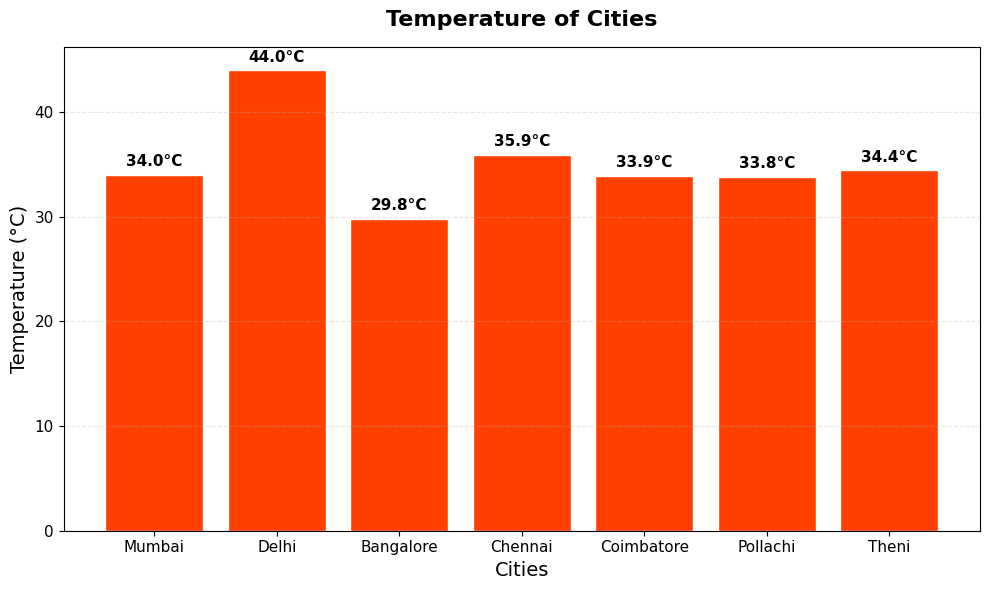

In [9]:
weather_df=pd.DataFrame(weather_records)
fig, ax=plt.subplots(figsize=(10, 6))
bars=ax.bar(
    weather_df['city'],
    weather_df['temperature'],
    color='#FF4000',
    edgecolor='white',
    linewidth=1
)
for bar in bars:
    height=bar.get_height()
    ax.text(
        bar.get_x()+bar.get_width()/2,
        height+0.5,
        f"{height}°C",
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold',
        color='black'
    )
ax.set_title(
    "Temperature of Cities",
    fontsize=16,
    fontweight='bold',
    pad=15
)
ax.set_xlabel("Cities",fontsize=14)
ax.set_ylabel("Temperature (°C)",fontsize=14)
ax.tick_params(axis='x',labelsize=11)
ax.tick_params(axis='y',labelsize=11)
ax.grid(axis='y',alpha=0.3,linestyle='--')
plt.tight_layout()
plt.show()